<font size = 10>\
    Projet 4 - Build a scoring model

Import usefull package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer

from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectFromModel

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedStratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

from sklearn.datasets import make_classification

from sklearn.dummy import DummyClassifier

from sklearn.utils import resample

from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

from sklearn.decomposition import PCA

from sklearn.kernel_ridge import KernelRidge

from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.base import BaseEstimator

# Load dataset

## Working with the Loan appplication data set

### Data

In [2]:
app_data = pd.read_csv('data/application_train.csv')
print('Training data shape: ', app_data.shape)

Training data shape:  (307511, 122)


### Kaggle Testing dataset

In [3]:
app_kaggle = pd.read_csv('data/application_test.csv')
print('Testing data shape: ', app_kaggle.shape)

Testing data shape:  (48744, 121)


# Exploratory Data Analysis

## Distribution of the target

In [17]:
app_data['TARGET'].value_counts()

0    282686
1     24825
Name: TARGET, dtype: int64

## Missing values

In [18]:
(app_data.isna().sum(axis = 0) / app_data.shape[0]).sort_values(ascending=False)[0:20]

COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
FLOORSMIN_MEDI              0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MODE               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MEDI               0.593767
dtype: float64

## Feature types

In [19]:
app_data.dtypes.value_counts()

float64    65
int64      41
object     16
dtype: int64

### Encoding Categorical Variables

Encode with labelEncoder for 2 unique categories or use get_dumies

In [78]:
from sklearn.preprocessing import LabelEncoder


# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_data:
    if app_data[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_data[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_data[col])
            # Transform both training and testing data
            app_data[col] = le.transform(app_data[col])
            app_kaggle[col] = le.transform(app_kaggle[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [79]:
# one-hot encoding of categorical variables
app_data = pd.get_dummies(app_data)
app_kaggle = pd.get_dummies(app_kaggle)

print('Training Features shape: ', app_data.shape)
print('Testing Features shape: ', app_kaggle.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)


In [80]:
train_labels = app_data['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_data, app_kaggle = app_data.align(app_kaggle, join = 'inner', axis = 1)

# Add the target back in
app_data['TARGET'] = train_labels

print('Training Features shape: ', app_data.shape)
print('Testing Features shape: ', app_kaggle.shape)

Training Features shape:  (307511, 240)
Testing Features shape:  (48744, 239)


In [81]:
app_data.to_pickle('data/app_data_encode_categ')
app_kaggle.to_pickle('data/app_kaggle_encode_categ')

In [82]:
app_data.shape

(307511, 240)

In [83]:
app_kaggle.shape

(48744, 239)

### Outliers in numerical features

In [84]:
app_data=pd.read_pickle('data/app_data_encode_categ')
app_kaggle=pd.read_pickle('data/app_kaggle_encode_categ')

In [85]:
app_data.shape

(307511, 240)

In [86]:
app_kaggle.shape

(48744, 239)

Print the describe function on the numerical columns to check for outliers

In [24]:
app_num=app_data.select_dtypes(include=['float64','int64'])

In [25]:
def show_describe(i):
    return app_num.describe().iloc[:,(i-1)*10:i*10]

In [26]:
widgets.interact(show_describe, i=10)

interactive(children=(IntSlider(value=10, description='i', max=30, min=-10), Output()), _dom_classes=('widget-…

<function __main__.show_describe(i)>

In [87]:
suspected_outliers=['DAYS_EMPLOYED',
                    'OBS_30_CNT_SOCIAL_CIRCLE',
                    'DEF_30_CNT_SOCIAL_CIRCLE',
                    'OBS_60_CNT_SOCIAL_CIRCLE',
                    'DEF_60_CNT_SOCIAL_CIRCLE',
                    'AMT_REQ_CREDIT_BUREAU_HOUR',
                    'AMT_REQ_CREDIT_BUREAU_DAY',
                    'AMT_REQ_CREDIT_BUREAU_WEEK',
                    'AMT_REQ_CREDIT_BUREAU_MON',
                    'AMT_REQ_CREDIT_BUREAU_QRT',
                    'AMT_REQ_CREDIT_BUREAU_YEAR',
                    'HOUR_APPR_PROCESS_START'
                   ]

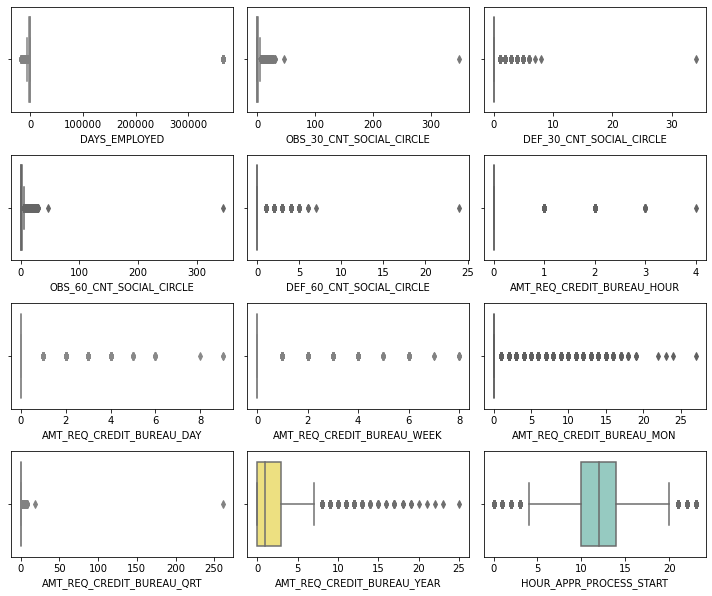

In [29]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

#### DAYS_EMPLOYED

In [88]:
app_data[app_data['DAYS_EMPLOYED']>200000].shape

(55374, 240)

<AxesSubplot:xlabel='DAYS_EMPLOYED'>

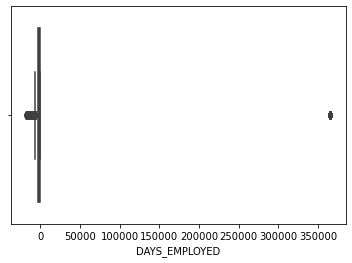

In [31]:
sns.boxplot(x=app_data['DAYS_EMPLOYED'])

In [97]:
# Create an anomalous flag column
app_data['DAYS_EMPLOYED_ANOM'] = app_data["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_data['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

# Apply the same steps to the test data
app_kaggle['DAYS_EMPLOYED_ANOM'] = app_kaggle["DAYS_EMPLOYED"] == 365243
app_kaggle["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)



#### Social circle features

In [98]:
app_data[app_data['OBS_30_CNT_SOCIAL_CIRCLE']>100].shape

(0, 241)

In [99]:
app_data.drop(index=app_data[app_data['OBS_30_CNT_SOCIAL_CIRCLE']>100].index,inplace=True)

<AxesSubplot:xlabel='DEF_30_CNT_SOCIAL_CIRCLE'>

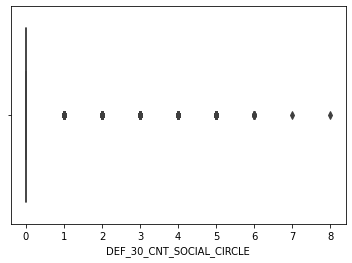

In [35]:
sns.boxplot(x=app_data['DEF_30_CNT_SOCIAL_CIRCLE'])

In [100]:
app_data[(app_data['DEF_30_CNT_SOCIAL_CIRCLE']>1.5) & (app_data['DEF_30_CNT_SOCIAL_CIRCLE']<2.5)].shape

(5323, 241)

In [101]:
app_data[(app_data['OBS_30_CNT_SOCIAL_CIRCLE']>15) & (app_data['OBS_30_CNT_SOCIAL_CIRCLE']<25)].shape

(418, 241)

<AxesSubplot:xlabel='DEF_60_CNT_SOCIAL_CIRCLE', ylabel='OBS_60_CNT_SOCIAL_CIRCLE'>

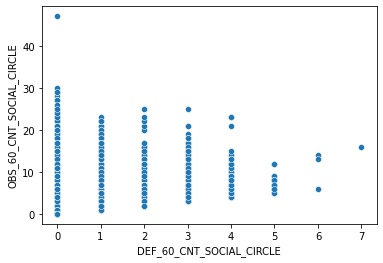

In [38]:
sns.scatterplot(x=app_data['DEF_60_CNT_SOCIAL_CIRCLE'],y=app_data['OBS_60_CNT_SOCIAL_CIRCLE'])

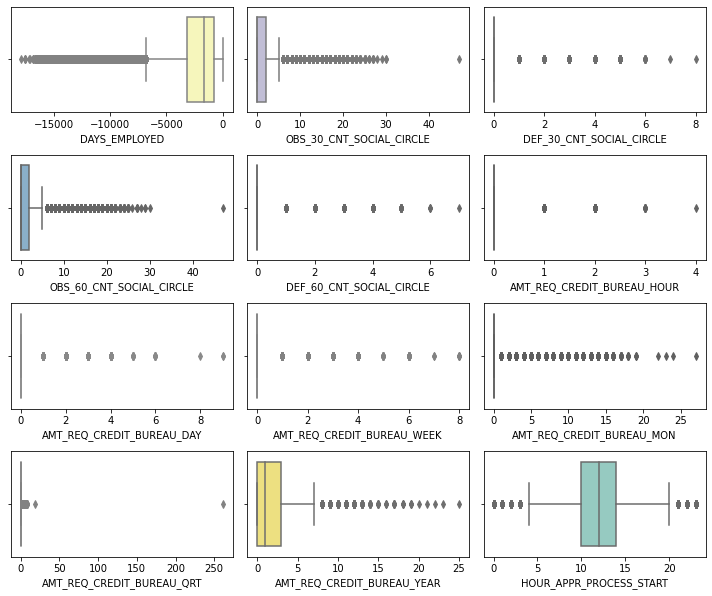

In [40]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

#### Amount of request features

<AxesSubplot:xlabel='AMT_REQ_CREDIT_BUREAU_QRT'>

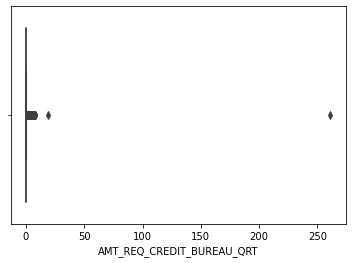

In [94]:
sns.boxplot(x=app_data['AMT_REQ_CREDIT_BUREAU_QRT'])

In [102]:
app_data[app_data['AMT_REQ_CREDIT_BUREAU_QRT']>15].shape

(0, 241)

In [103]:
app_data.drop(index=app_data[app_data['AMT_REQ_CREDIT_BUREAU_QRT']>15].index,inplace=True)

<AxesSubplot:xlabel='AMT_REQ_CREDIT_BUREAU_QRT'>

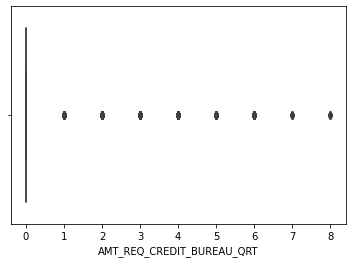

In [46]:
sns.boxplot(x=app_data['AMT_REQ_CREDIT_BUREAU_QRT'])

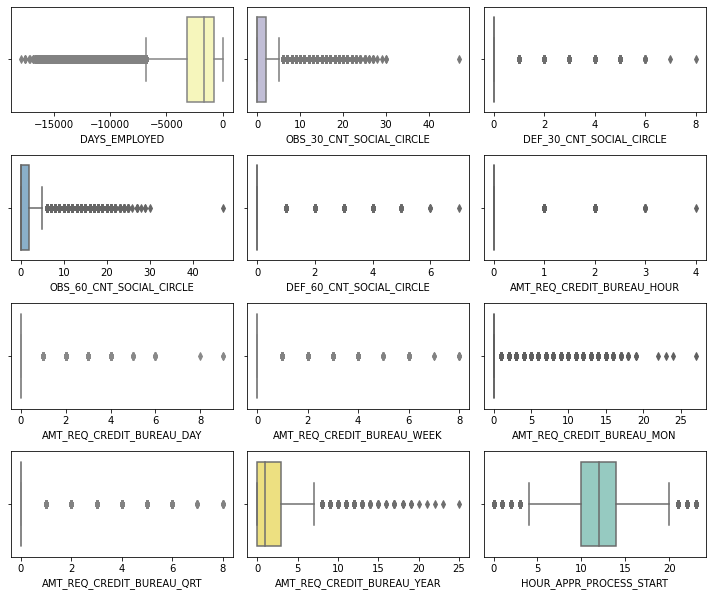

In [47]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_data[col],color=colors[i%12])
plt.tight_layout()

## SK_ID_CURR

In [315]:
app_data.index = app_data['SK_ID_CURR']
app_kaggle.index = app_kaggle['SK_ID_CURR']

In [317]:
app_data = app_data.drop(columns=['SK_ID_CURR'])
app_kaggle = app_kaggle.drop(columns=['SK_ID_CURR'])

## Saving datasets

In [320]:
app_data.to_pickle('data/app_data_outliers')
app_kaggle.to_pickle('data/app_kaggle_outliers')

## Correlations

In [2]:
app_data=pd.read_pickle('data/app_data_outliers')
app_kaggle=pd.read_pickle('data/app_kaggle_outliers')
print('app_data shape :', app_data.shape)
print('app_kaggle shape :',app_kaggle.shape)

app_data shape : (307508, 240)
app_kaggle shape : (48744, 239)


In [50]:
# correlation_matrix=app_data.corr()

In [51]:
# correlation_matrix.to_pickle('data/correlation_matrix')

In [52]:
correlation_matrix=pd.read_pickle('data/correlation_matrix')

In [53]:
np.fill_diagonal(correlation_matrix.values,0)

In [54]:
correlation_abs_matrix = correlation_matrix.abs()

In [55]:
corr_max_abs = pd.DataFrame(correlation_abs_matrix.idxmax(axis=0),columns=['feature'])

In [56]:
corr_max_abs['corr_coef']=correlation_abs_matrix.max(axis=0)

In [57]:
corr_max_abs.sort_values('corr_coef',ascending=False,inplace=True)

In [58]:
correlation_abs_matrix['TARGET'].sort_values(ascending=False).head(20)

EXT_SOURCE_3                                         0.178920
EXT_SOURCE_2                                         0.160448
EXT_SOURCE_1                                         0.155319
DAYS_BIRTH                                           0.078251
DAYS_EMPLOYED                                        0.074954
REGION_RATING_CLIENT_W_CITY                          0.060897
REGION_RATING_CLIENT                                 0.058903
NAME_INCOME_TYPE_Working                             0.057472
NAME_EDUCATION_TYPE_Higher education                 0.056585
DAYS_LAST_PHONE_CHANGE                               0.055208
CODE_GENDER_M                                        0.054723
CODE_GENDER_F                                        0.054714
DAYS_ID_PUBLISH                                      0.051451
REG_CITY_NOT_WORK_CITY                               0.051003
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049815
NAME_INCOME_TYPE_Pensioner                           0.046206
ORGANIZA

# Baseline

In [5]:
def show_score(y_test,y_pred_d_cls_prob,y_pred_d_cls):
    a=roc_auc_score(y_test,y_pred_d_cls_prob)
    b=f1_score(y_test,y_pred_d_cls)
    c=accuracy_score(y_test,y_pred_d_cls)
    d=precision_score(y_test,y_pred_d_cls)
    e=recall_score(y_test,y_pred_d_cls)
    print('ROC AUC   :',a)
    print('F1        :',b)
    print('Accuracy  :',c)
    print('Precision :',d)
    print('Recall    :',e)

## Test and Train split

In [3]:
X = app_data.drop( columns = ['TARGET'])
y = app_data['TARGET']
features = X.columns

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [100]:
X.shape

(307508, 239)

## Imputation of data

### Using SimpleImputer

In [8]:
simple_imputer = SimpleImputer(strategy = 'median')

## Standardization

In [9]:
scaler = StandardScaler()

In [12]:
pipeline_basic = make_pipeline(simple_imputer,scaler)
pipeline_basic.fit(X_train,y_train)
X_train_std = pipeline_basic.transform(X_train)
X_test_std = pipeline_basic.transform(X_test)

## Dummy classifier

In [13]:
cv = RepeatedStratifiedKFold(n_splits=10,n_repeats=3,random_state=1)
scoring = {'ROC AUC': 'roc_auc',
           'F1': 'f1',
           'Accuracy': 'accuracy',
           'Precision' : 'precision',
           'Recall' :'recall'}

In [14]:
dummy_cls = make_pipeline(simple_imputer,scaler,DummyClassifier(strategy='stratified'))

In [15]:
scores = cross_validate(dummy_cls,X_train,y_train, scoring = scoring, cv=cv)
for key in scores.keys():
    print (f'Mean {key} : {scores[key].mean()}' )

Mean fit_time : 16.78292257785797
Mean score_time : 1.1669269720713298
Mean test_ROC AUC : 0.5004593887127833
Mean test_F1 : 0.0824721360440806
Mean test_Accuracy : 0.8521200877131665
Mean test_Precision : 0.08260318652456142
Mean test_Recall : 0.08235722627092046


## Kaggle Submission

In [78]:
def kaggle_submit(estimator,data,output_name = 'submission_default.csv'):
    kaggle_pred = estimator.predict_proba(data)[:,1]
    kaggle_df = pd.DataFrame(data.index,columns=['SK_ID_CURR'])
    kaggle_df['TARGET'] = kaggle_pred
    kaggle_df.to_csv('data/'+output_name,index = False)

In [17]:
dummy_cls.fit(X_train,y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('dummyclassifier', DummyClassifier(strategy='stratified'))])

In [18]:
kaggle_submit(dummy_cls,app_kaggle,output_name='dummy_classifier.csv')

Kaggle gives 0.49

# Undersampling

In [342]:
X_train_under, y_train_under = resample(X_train,y_train,n_samples = 50000, stratify = y_train,random_state=2)

# Feature Importance

In [343]:
def features_importance_lg(estimator,features,n_features_plot = 40,plot = False):
    
    estimator_coef=pd.DataFrame(estimator.coef_.reshape(features.shape[0],),columns=['coeff'])
    estimator_coef['abs_coeff']=np.abs(estimator_coef['coeff'])
    estimator_coef['relative_importance']=estimator_coef['coeff'] / estimator_coef['abs_coeff'].sum()
    estimator_coef['abs_relative_importance']=estimator_coef['abs_coeff']/estimator_coef['abs_coeff'].sum()
    estimator_coef['sign']=np.sign(estimator_coef['coeff'])
    estimator_coef['feature']=features.values
    estimator_coef = estimator_coef.sort_values(by='abs_relative_importance',ascending=False)
    
    if plot == True:
        plt.figure(figsize=(10,10))
        sns.barplot(data=estimator_coef.head(n_features_plot),x ='relative_importance',y='feature',hue='sign',dodge=False)
        
    return estimator_coef

In [344]:
def features_importance_rdf(estimator,features,n_features_plot = 40, plot = False):
    
    estimator_coef=pd.DataFrame(estimator.feature_importances_.reshape(features.shape[0],),columns=['coeff'])
    estimator_coef['importance']=np.abs(estimator_coef['coeff'])
    estimator_coef['abs_relative_importance']=estimator_coef['importance']/estimator_coef['importance'].sum()
    estimator_coef['sign']=np.sign(estimator_coef['coeff'])
    estimator_coef['feature']=features.values
    estimator_coef = estimator_coef.sort_values(by='abs_relative_importance',ascending=False)
    
    if plot == True:
        plt.figure(figsize=(10,10))
        sns.barplot(data=estimator_coef.head(n_features_plot),x ='abs_relative_importance',y='feature',hue='sign',dodge=False)
        
    return estimator_coef

In [345]:
feature_importance={}

## Decision tree

In [347]:
pipeline_tree = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('tree' , DecisionTreeClassifier(class_weight='balanced'))]) 
                        

In [348]:
pipeline_tree.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('tree', DecisionTreeClassifier(class_weight='balanced'))])

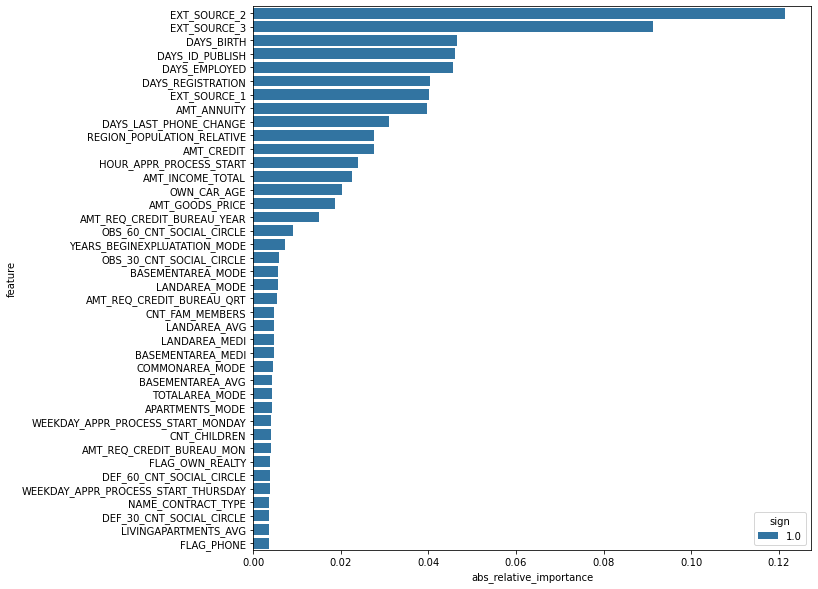

In [349]:
feature_importance['tree'] = features_importance_rdf(pipeline_tree.named_steps['tree'],features,plot=True)

## LDA

In [350]:
pipeline_lda = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('lda' , LinearDiscriminantAnalysis())]) 

In [351]:
pipeline_lda.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lda', LinearDiscriminantAnalysis())])

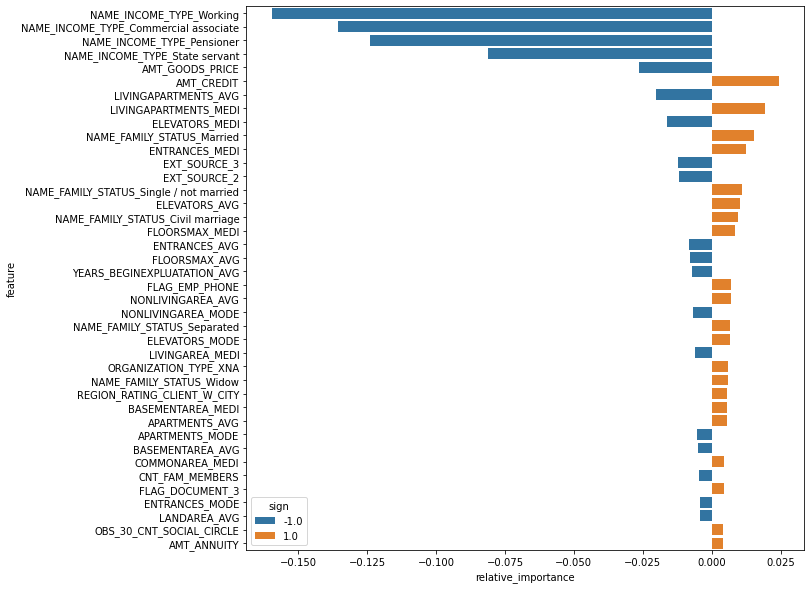

In [352]:
feature_importance['lda'] = features_importance_lg(pipeline_lda.named_steps['lda'],features,plot=True)

## Logistic regression

In [9]:
pipeline_lr = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('lr' , LogisticRegression(C = 0.01, max_iter = 200, class_weight = 'balanced'))]) 

In [354]:
pipeline_lr.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=200))])

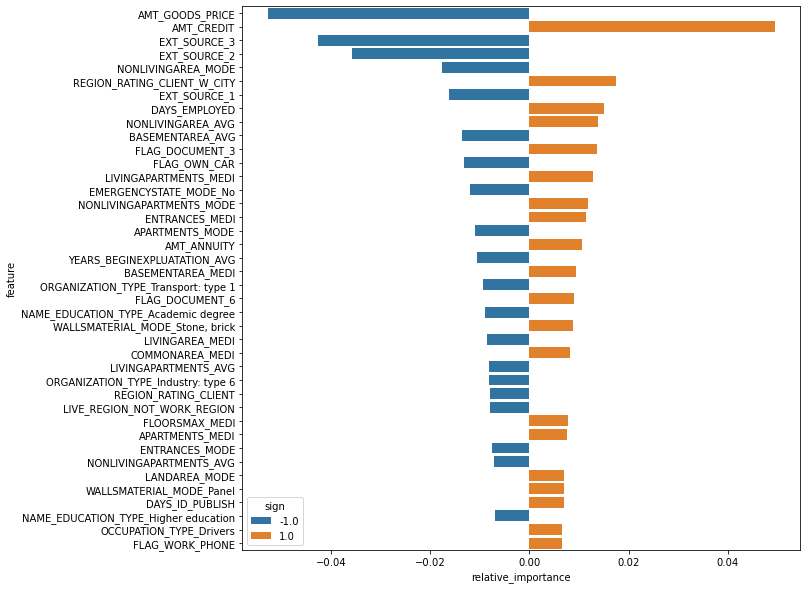

In [355]:
feature_importance['lr'] = features_importance_lg(pipeline_lr.named_steps['lr'],features,plot=True)

## Random forest

In [13]:
pipeline_rdf = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('rdf' , RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'))]) 

In [357]:
pipeline_rdf.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('rdf', RandomForestClassifier(class_weight='balanced'))])

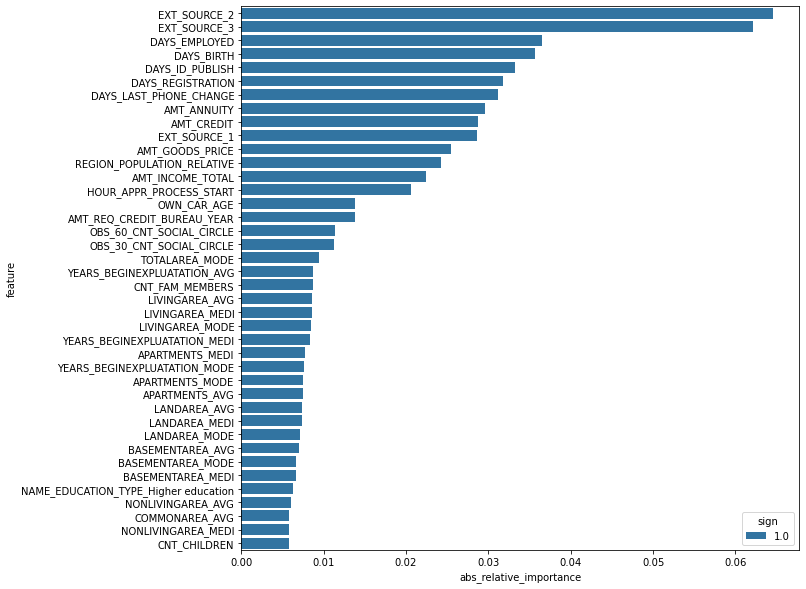

In [358]:
feature_importance['rdf'] = features_importance_rdf(pipeline_rdf.named_steps['rdf'],features,plot = True)

## SGD Classifier

In [11]:
pipeline_sgd = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('sgd' , SGDClassifier(class_weight='balanced',loss='modified_huber'))]) 

In [360]:
pipeline_sgd.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('sgd',
                 SGDClassifier(class_weight='balanced',
                               loss='modified_huber'))])

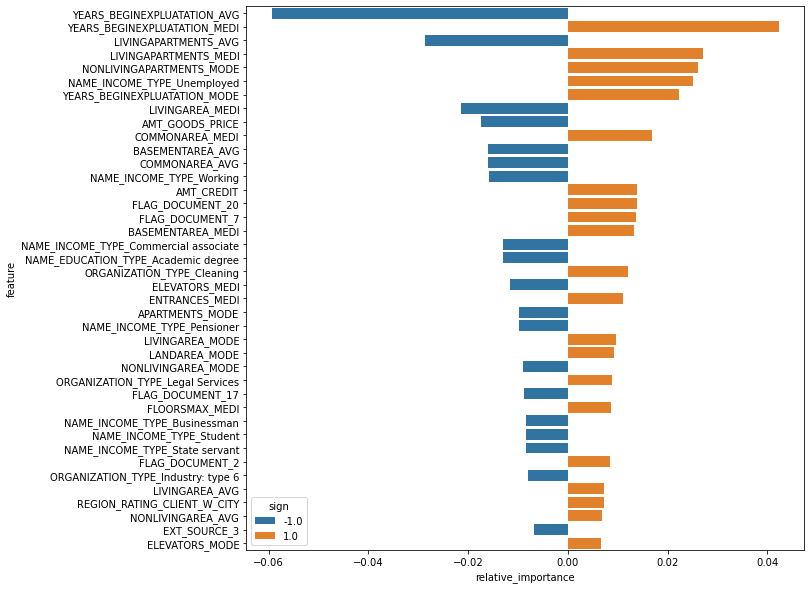

In [361]:
feature_importance['SGDClassifier'] = features_importance_lg(pipeline_sgd.named_steps['sgd'],features,plot = True)

## LGB

In [12]:
pipeline_lgb = Pipeline(
                        [('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('lgb' , LGBMClassifier(class_weight='balanced'))]) 

In [363]:
pipeline_lgb.fit(X_train_under,y_train_under)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lgb', LGBMClassifier(class_weight='balanced'))])

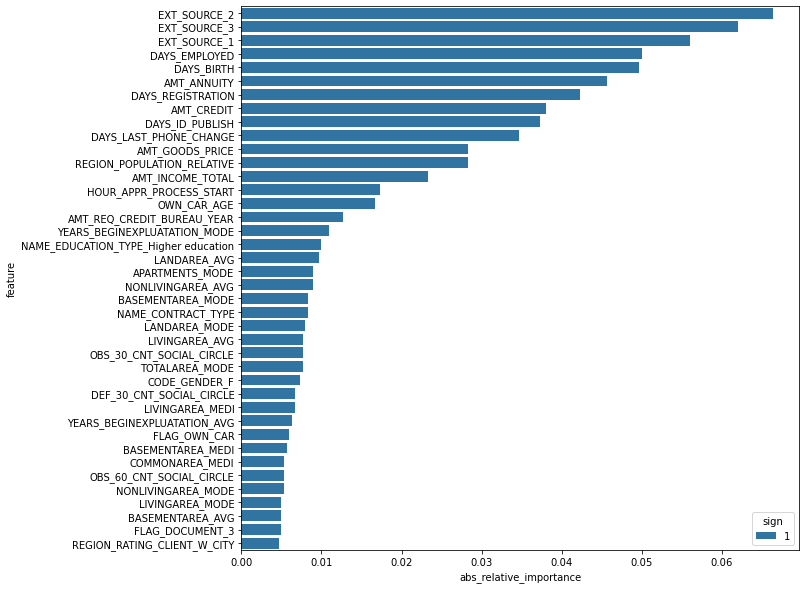

In [364]:
feature_importance['lgb'] = features_importance_rdf(pipeline_lgb.named_steps['lgb'],features,plot = True)

## Feature importance results

In [365]:
feature_importance.keys()

dict_keys(['tree', 'lda', 'lr', 'rdf', 'SGDClassifier', 'lgb'])

In [366]:
feature_importance_results = pd.DataFrame(index = features)
feature_importance_results['counts']=0
feature_importance_results['rank']=0
feature_importance_results['total importance']=0
feature_importance_results['appearance in top 40']=0

In [367]:
for key in feature_importance.keys():
    n = 0
    for feature in feature_importance[key]['feature']:
        if n <= 30:
            feature_importance_results.loc[feature,'counts']+=1
        feature_importance_results.loc[feature,'rank']+=n
        feature_importance_results.loc[feature,'total importance']+= feature_importance[key].where(feature_importance[key]['feature'] == feature )['abs_relative_importance'].sum()
        n+=1
feature_importance_results['total importance'] = feature_importance_results['total importance'] / feature_importance_results['total importance'].sum()
    

In [368]:
top_40_counts_index = feature_importance_results.sort_values(by=['counts'],ascending=False).head(40).index
feature_importance_results.loc[top_40_counts_index,'appearance in top 40']+=1

top_40_importance_index = feature_importance_results.sort_values(by=['total importance'],ascending=False).head(40).index
feature_importance_results.loc[top_40_importance_index,'appearance in top 40']+=1

top_40_rank_index = feature_importance_results.sort_values(by=['rank'],ascending=True).head(40).index
feature_importance_results.loc[top_40_rank_index,'appearance in top 40']+=1

In [369]:
feature_importance_results.sort_values(by=['appearance in top 40','total importance'],ascending=False).head(40)

,counts,rank,total importance,appearance in top 40
EXT_SOURCE_2,5,56,0.051013,3
EXT_SOURCE_3,5,54,0.046202,3
AMT_CREDIT,6,44,0.030330,3
AMT_GOODS_PRICE,6,46,0.028173,3
DAYS_EMPLOYED,4,221,0.025247,3
EXT_SOURCE_1,4,133,0.024734,3
AMT_ANNUITY,4,152,0.022131,3
DAYS_ID_PUBLISH,3,288,0.021106,3
DAYS_REGISTRATION,3,233,0.020777,3
YEARS_BEGINEXPLUATATION_AVG,5,161,0.015719,3


## Reducing number of feature

In [415]:
score = 'f1'

### optimisation of number of feature

In [402]:
params = {'feature_selection__max_features':np.arange(20,100,10)}

In [424]:
def opt_feat(estimator,params,X,y,score):
    pipeline = Pipeline([('imp', SimpleImputer(strategy='median')),
                         ('scaler' , StandardScaler()),
                         ('feature_selection', SelectFromModel(estimator)),
                         ('tree' , estimator)])
    CV = GridSearchCV(pipeline,
                      param_grid = params,
                      scoring = score,
                      verbose=True,
                      cv=5)
    CV.fit(X,y)
    print (f'{CV.best_params_}')
    return CV

#### Decision tree

In [426]:
CV_tree_max_feat = opt_feat(DecisionTreeClassifier(class_weight='balanced'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:  5.0min finished


{'feature_selection__max_features': 90}


#### LDA

In [432]:
CV_lda_max_feat = opt_feat(LinearDiscriminantAnalysis(),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:  3.2min finished


{'feature_selection__max_features': 40}


#### Logistic regression

In [427]:
CV_lr_max_feat = opt_feat(LogisticRegression(C = 0.01, max_iter = 1000, class_weight = 'balanced'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:  3.5min finished


{'feature_selection__max_features': 80}


#### Random Forest

In [429]:
CV_rdf_max_feat = opt_feat(RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed: 18.6min finished


{'feature_selection__max_features': 50}


#### SGD

In [431]:
CV_sgd_max_feat = opt_feat(SGDClassifier(class_weight='balanced',loss='modified_huber'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:  4.4min finished


{'feature_selection__max_features': 90}


#### LGB

In [433]:
CV_lgb_max_feat = opt_feat( LGBMClassifier(class_weight='balanced'),params,X_train_under,y_train_under,score)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:  3.7min finished


{'feature_selection__max_features': 50}


### Effect on Logistic regression

In [5]:
pipeline_lr_red = Pipeline( [('imp', SimpleImputer(strategy='median')),
                            ('scaler' , StandardScaler()),
                            ('feature_selection', SelectFromModel(LogisticRegression(C = 0.01, max_iter = 200, class_weight = 'balanced'),
                                                                  max_features=80)),
                            ('lr' , LogisticRegression(C = 0.01, max_iter = 200, class_weight = 'balanced'))])

In [6]:
pipeline_lr_red.fit(X_train,y_train)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(C=0.01,
                                                              class_weight='balanced',
                                                              max_iter=200),
                                 max_features=80)),
                ('lr',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=200))])

In [24]:
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=2,random_state=1)
scoring = {'ROC AUC': 'roc_auc',
           'F1': 'f1',
           'Accuracy': 'accuracy',
           'Precision' : 'precision',
           'Recall' :'recall'}

In [10]:
scores['lr'] = cross_validate(pipeline_lr,X_train,y_train, scoring = scoring, cv=cv)
scores['lr_red'] = cross_validate(pipeline_lr_red,X_train,y_train, scoring = scoring, cv=cv)

### Effect on SGD

In [14]:
pipeline_sgd_red = Pipeline( [('imp', SimpleImputer(strategy='median')),
                            ('scaler' , StandardScaler()),
                            ('feature_selection', SelectFromModel(SGDClassifier(class_weight='balanced',loss='modified_huber'),
                                                                  max_features=90)),
                            ('sgd' , SGDClassifier(class_weight='balanced',loss='modified_huber'))])

In [15]:
pipeline_sgd_red.fit(X_train,y_train)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=SGDClassifier(class_weight='balanced',
                                                         loss='modified_huber'),
                                 max_features=90)),
                ('sgd',
                 SGDClassifier(class_weight='balanced',
                               loss='modified_huber'))])

In [16]:
scores['sgd'] = cross_validate(pipeline_sgd,X_train,y_train, scoring = scoring, cv=cv)
scores['sgd_red'] = cross_validate(pipeline_sgd_red,X_train,y_train, scoring = scoring, cv=cv)

### Effect on Random Forest

In [26]:
pipeline_rdf_red = Pipeline( [('imp', SimpleImputer(strategy='median')),
                            ('scaler' , StandardScaler()),
                            ('feature_selection', SelectFromModel(
                                        RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'),
                                                                  max_features=50)),
                            ('rdf' , RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'))])

In [ ]:
pipeline_rdf_red.fit(X_train,y_train)

In [ ]:
scores['rdf'] = cross_validate(pipeline_rdf,X_train,y_train, scoring = scoring, cv=cv)
scores['rdf_red'] = cross_validate(pipeline_rdf_red,X_train,y_train, scoring = scoring, cv=cv)

### Effect on LGB

In [21]:
pipeline_lgb_red = Pipeline( [('imp', SimpleImputer(strategy='median')),
                            ('scaler' , StandardScaler()),
                            ('feature_selection', SelectFromModel(LGBMClassifier(class_weight='balanced'),
                                                                  max_features=50)),
                            ('lgb' , LGBMClassifier(class_weight='balanced'))])

In [22]:
pipeline_lgb_red.fit(X_train,y_train)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                 max_features=50)),
                ('lgb', LGBMClassifier(class_weight='balanced'))])

In [25]:
scores['lgb'] = cross_validate(pipeline_lgb,X_train,y_train, scoring = scoring, cv=cv)
scores['lgb_red'] = cross_validate(pipeline_lgb_red,X_train,y_train, scoring = scoring, cv=cv)

In [ ]:
scores.keys()

### Comparing performances

In [17]:
scores_pd=pd.DataFrame(index = pd.Index(scores.keys()))

In [18]:
for model in scores.keys():
    for scoring in scores[model]:
        scores_pd.loc[model,scoring]=scores[model][scoring].mean()

In [20]:
scores_pd

,fit_time,score_time,test_ROC AUC,test_F1,test_Accuracy,test_Precision,test_Recall
lr,25.605710,2.112813,0.746358,0.259200,0.687965,0.160318,0.676393
lr_red,30.377484,2.232792,0.742798,0.256342,0.685570,0.158408,0.671486
sgd,45.092805,2.497753,0.676986,0.217413,0.628332,0.131078,0.638848
sgd_red,50.448320,2.538403,0.688331,0.222176,0.630885,0.134239,0.650794


In [19]:
scores_pd.to_pickle('data/scores_feature_selection')

# Feature Engineering

In [370]:
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=2,random_state=1)
scoring = {'ROC AUC': 'roc_auc',
           'F1': 'f1',
           'Accuracy': 'accuracy',
           'Precision' : 'precision',
           'Recall' :'recall'}


In [ ]:
scores={}

## Synthetic features using PCA

In [ ]:
pca = PCA(n_components=2)
pca.fit(X_train_std)
pca.explained_variance_ratio_

In [ ]:
PC1 = pd.DataFrame(pca.components_[0],columns=['coef'])
PC1['feature'] = features
PC2 = pd.DataFrame(pca.components_[1],columns=['coef'])
PC2['feature'] = features

In [ ]:
PC1 = PC1.sort_values(by='coef',ascending=False)
PC2 = PC2.sort_values(by='coef',ascending=False)

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(data=PC1.head(30),x ='coef',y='feature')

In [ ]:
plt.figure(figsize=(10,10))
sns.barplot(data=PC2.head(30),x ='coef',y='feature')

In [ ]:
X_train_pca = pca.transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

In [ ]:
X_train_pca = np.hstack((X_train_std,X_train_pca))
X_test_pca = np.hstack((X_test_std,X_test_pca))

In [ ]:
features_pca = features.append(pd.Index(['PC1','PC2']))

In [ ]:
X_train_pca.shape

In [ ]:
lg = LogisticRegression(C=0.001,class_weight='balanced')
lg.fit(X_train_pca,y_train)

In [ ]:
A =features_importance_lg(lg,features_pca,n_features=40,plot = True)

In [ ]:
rdf.fit(X_train_pca,y_train)

In [ ]:
A = features_importance_rdf(rdf,features_pca,n_features=40,plot = True)

## Business Features

### Creating the features

In [109]:
def create_features(df):
        data = df.copy()
        data.loc[:,'ANNUITY_INCOME_RATIO'] = data['AMT_ANNUITY'] / data['AMT_INCOME_TOTAL']
        data.loc[:,'CREDIT_INCOME_RATIO'] = data['AMT_CREDIT'] / data['AMT_INCOME_TOTAL']
        data.loc[:,'DAYS_EMPLOYED_DAYS_BIRTH_RATIO'] = data['DAYS_EMPLOYED'] / data['DAYS_BIRTH']
        data.loc[:,'TOTAL_CREDIT_LENGTH_MONTH'] = data['AMT_CREDIT'] / data['AMT_ANNUITY']
        return data

In [237]:
features_busi= create_features(app_kaggle).columns

### Logistic Regression

In [267]:
pipeline_lr_red_busi = Pipeline(
                            [('feature_eng', FunctionTransformer(func=create_features)),
                             ('imp', SimpleImputer(strategy='median')),
                             ('scaler', StandardScaler()),
                             ('feature_selection', SelectFromModel(LogisticRegression(C = 0.01, max_iter = 200, class_weight = 'balanced'),
                                                                  max_features=40)),
                             ('lr', LogisticRegression(class_weight='balanced',max_iter = 1000))]
                             )
                            

In [269]:
pipeline_lr_red_busi.fit(X_train_under,y_train_under)

Pipeline(steps=[('feature_eng',
                 FunctionTransformer(func=<function create_features at 0x00000180806303A0>)),
                ('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(C=0.01,
                                                              class_weight='balanced',
                                                              max_iter=200),
                                 max_features=40)),
                ('lr',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [270]:
selected_features = features_busi[pipeline_lr_red_busi.named_steps['feature_selection'].get_support()]

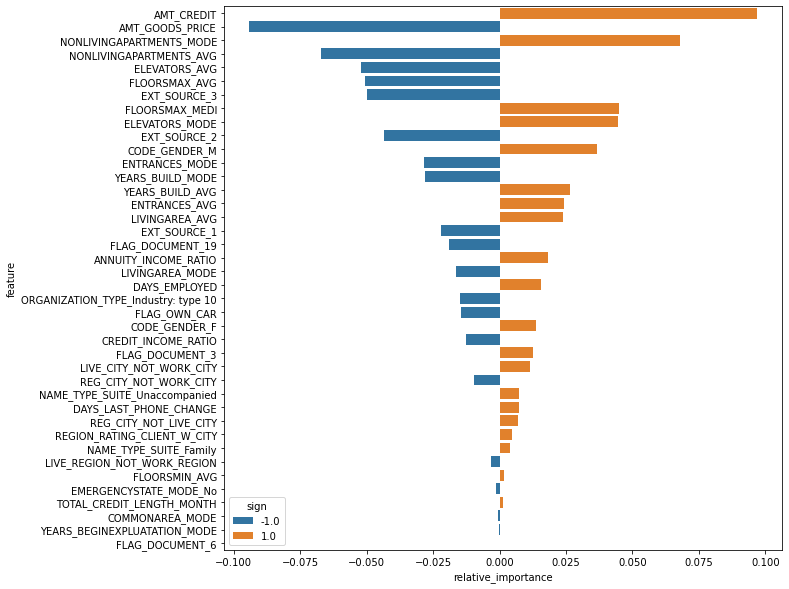

In [271]:
A = features_importance_lg(pipeline_lr_red_busi.named_steps['lr'],selected_features,plot=True)

In [279]:
scores['lr'] = cross_validate(pipeline_lr,X_train_under,y_train_under, scoring = scoring, cv=cv)
scores['lr_red'] = cross_validate(pipeline_lr_red,X_train_under,y_train_under, scoring = scoring, cv=cv)
scores['lr_red_busi'] = cross_validate(pipeline_lr_red_busi,X_train_under,y_train_under, scoring = scoring, cv=cv)

### Random Forest

In [299]:
pipeline_rdf_red_busi = Pipeline(
                            [('feature_eng', FunctionTransformer(func=create_features)),
                             ('imp', SimpleImputer(strategy='median')),
                             ('scaler', StandardScaler()),
                              ('feature_selection', SelectFromModel(
                                        RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'),
                                                                  max_features=40)),
                             ('rdf' , RandomForestClassifier(n_estimators= 100, class_weight="balanced",criterion='gini'))]
                             )

In [300]:
pipeline_rdf_red_busi.fit(X_train_under,y_train_under)

Pipeline(steps=[('feature_eng',
                 FunctionTransformer(func=<function create_features at 0x00000180806303A0>)),
                ('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=RandomForestClassifier(class_weight='balanced'),
                                 max_features=40)),
                ('rdf', RandomForestClassifier(class_weight='balanced'))])

In [301]:
selected_features = features_busi[pipeline_rdf_red_busi.named_steps['feature_selection'].get_support()]

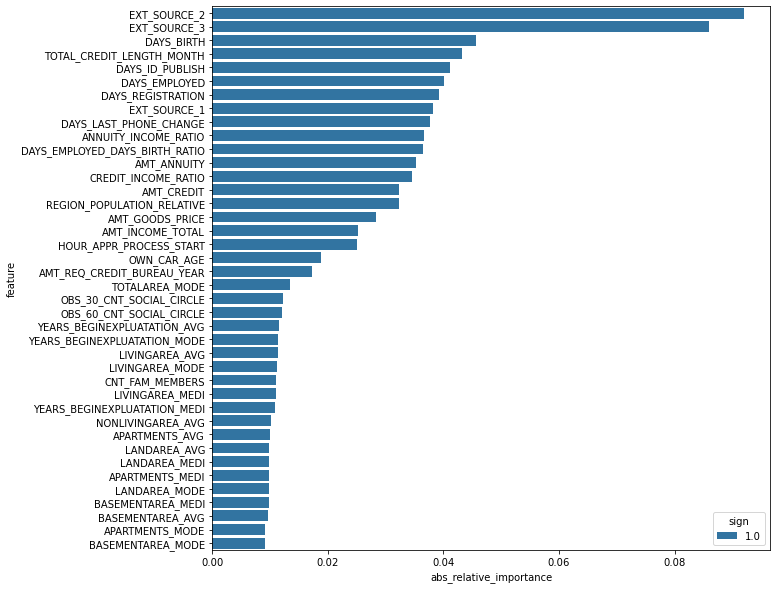

In [302]:
A = features_importance_rdf(pipeline_rdf_red_busi.named_steps['rdf'],selected_features,plot=True)

In [286]:
scores['rdf'] = cross_validate(pipeline_rdf,X_train_under,y_train_under, scoring = scoring, cv=cv)
scores['rdf_red'] = cross_validate(pipeline_rdf_red,X_train_under,y_train_under, scoring = scoring, cv=cv)
scores['rdf_red_busi'] = cross_validate(pipeline_rdf_red_busi,X_train_under,y_train_under, scoring = scoring, cv=cv)

### SGDClassifier

In [304]:
pipeline_sgd_red_busi = Pipeline(
                            [('feature_eng', FunctionTransformer(func=create_features)),
                             ('imp', SimpleImputer(strategy='median')),
                             ('scaler', StandardScaler()),
                             ('feature_selection', SelectFromModel(SGDClassifier(class_weight='balanced',loss='modified_huber'),
                                                                  max_features=40)),
                             ('sgd', SGDClassifier(class_weight='balanced',loss='modified_huber'))]
                             )

In [305]:
pipeline_sgd_red_busi.fit(X_train_under,y_train_under)

Pipeline(steps=[('feature_eng',
                 FunctionTransformer(func=<function create_features at 0x00000180806303A0>)),
                ('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=SGDClassifier(class_weight='balanced',
                                                         loss='modified_huber'),
                                 max_features=40)),
                ('sgd',
                 SGDClassifier(class_weight='balanced',
                               loss='modified_huber'))])

In [306]:
selected_features = features_busi[pipeline_sgd_red_busi.named_steps['feature_selection'].get_support()]

In [317]:
selected_features

Index(['FLAG_OWN_CAR', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'EXT_SOURCE_3', 'APARTMENTS_AVG',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'ELEVATORS_AVG',
       'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG',
       'LIVINGAREA_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
       'ELEVATORS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'APARTMENTS_MEDI',
       'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'FLOORSMAX_MEDI',
       'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI',
       'NONLIVINGAPARTMENTS_MEDI', 'FLAG_DOCUMENT_19',
       'NAME_TYPE_SUITE_Group of people', 'NAME_INCOME_TYPE_Businessman',
       'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner',
       'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Unemployed',
       'NAME_INCOME_TYPE_Working', 'ORGANIZATION_TYPE_Industry: type 10',
       'ORGANIZATION_TYPE_Industry: type 6',
       'ORGANIZATION_TYPE_Industry: type 

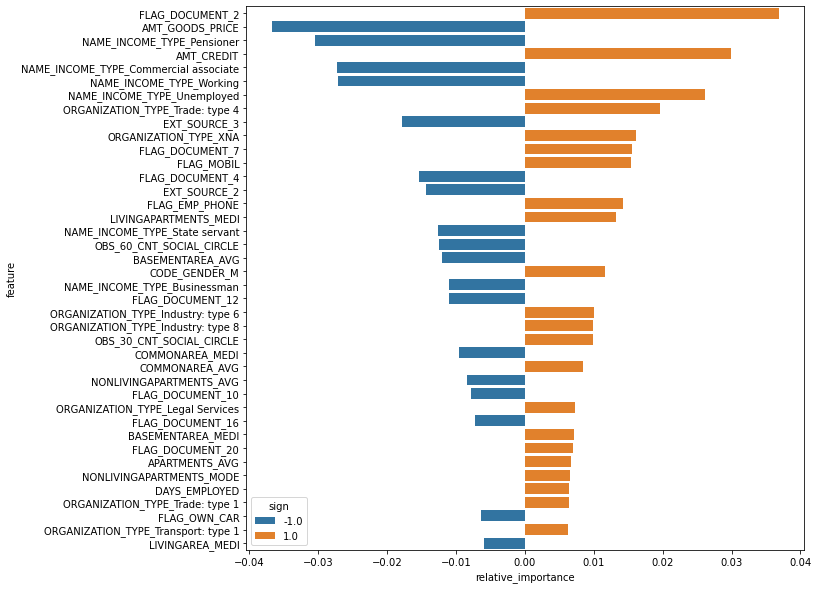

In [307]:
A = features_importance_lg(pipeline_sgd_busi.named_steps['sgd'],selected_features_busi,plot=True)

In [308]:
scores['sgd'] = cross_validate(pipeline_sgd,X_train_under,y_train_under, scoring = scoring, cv=cv)
scores['sgd_red'] = cross_validate(pipeline_sgd_red,X_train_under,y_train_under, scoring = scoring, cv=cv)
scores['sgd_red_busi'] = cross_validate(pipeline_sgd_red_busi,X_train_under,y_train_under, scoring = scoring, cv=cv)

### LGB

In [331]:
pipeline_lgb_red_busi = Pipeline(
                            [('feature_eng', FunctionTransformer(func=create_features)),
                             ('imp', SimpleImputer(strategy='median')),
                             ('scaler', StandardScaler()),
                             ('feature_selection', SelectFromModel(LGBMClassifier(class_weight='balanced'),
                                                                    max_features=40)),
                             ('lgb' , LGBMClassifier(class_weight='balanced'))]
                             )

In [332]:
pipeline_lgb_red_busi.fit(X_train_under,y_train_under)

Pipeline(steps=[('feature_eng',
                 FunctionTransformer(func=<function create_features at 0x00000180806303A0>)),
                ('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('feature_selection',
                 SelectFromModel(estimator=LGBMClassifier(class_weight='balanced'),
                                 max_features=40)),
                ('lgb', LGBMClassifier(class_weight='balanced'))])

In [333]:
selected_features = features_busi[pipeline_lgb_red_busi.named_steps['feature_selection'].get_support()]

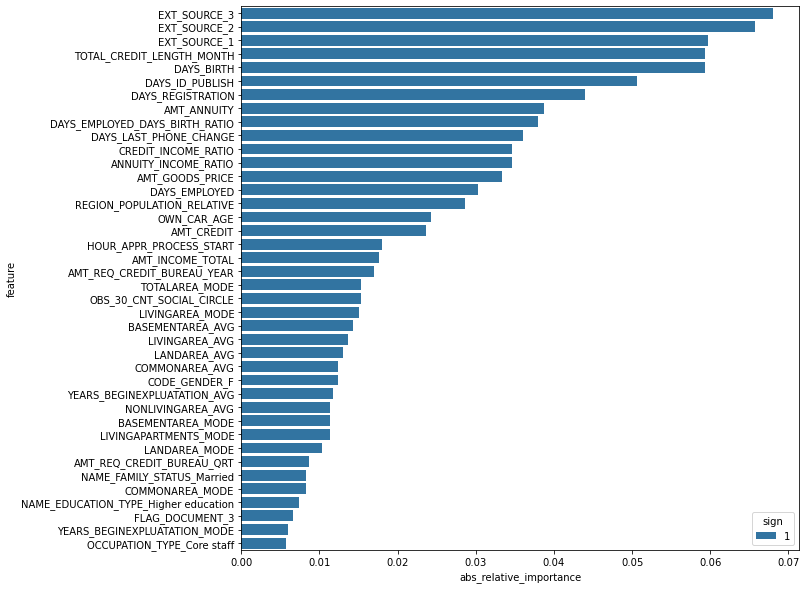

In [334]:
A = features_importance_rdf(pipeline_lgb_red_busi.named_steps['lgb'],selected_features,plot=True)

In [337]:
scores['lgb'] = cross_validate(pipeline_lgb,X_train_under,y_train_under, scoring = scoring, cv=cv)
scores['lgb_red'] = cross_validate(pipeline_lgb_red,X_train_under,y_train_under, scoring = scoring, cv=cv)
scores['lgb_red_busi'] = cross_validate(pipeline_lgb_red_busi,X_train_under,y_train_under, scoring = scoring, cv=cv)

In [338]:
for model in scores.keys():
    for scoring in scores[model]:
        scores_pd.loc[model,scoring]=scores[model][scoring].mean()

In [340]:
scores_pd.sort_values(by='test_F1')

,fit_time,score_time,test_ROC AUC,test_F1,test_Accuracy,test_Precision,test_Recall
sgd_red_busi,7.899411,0.665870,0.582528,0.174521,0.52939,0.103514,0.606320
sgd_red,7.240861,0.522466,0.589408,0.177717,0.55210,0.105448,0.590706
sgd,7.198696,0.553611,0.631182,0.193939,0.59210,0.115464,0.607063
rdf_red,12.930993,1.058805,0.687998,0.246600,0.90904,0.525935,0.181908
rdf,17.032044,1.053049,0.769122,0.249530,0.93077,0.995725,0.142751
lr_red_busi,5.533328,0.622020,0.735481,0.251752,0.68370,0.155583,0.659356
rdf_red_busi,17.235192,1.309010,0.768476,0.252951,0.93067,0.969213,0.145601
lr_red,4.506278,0.525635,0.735116,0.253110,0.68551,0.156567,0.660347
lr,4.049238,0.500427,0.740530,0.255553,0.68911,0.158389,0.661214
lgb_red,6.213503,0.710352,0.754135,0.286833,0.75926,0.188499,0.599752


# Model selection

## Undersampling

In [262]:
X_train_under, y_train_under = resample(X_train,y_train,n_samples = 50000, stratify = y_train)

## Kfold cross validation

In [371]:
scores = {}

In [372]:
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=2,random_state=1)
scoring = {'ROC AUC': 'roc_auc',
           'F1': 'f1',
           'Accuracy': 'accuracy',
           'Precision' : 'precision',
           'Recall' :'recall'}

In [373]:
Model_list = {'pipeline_tree':pipeline_tree,
              'pipeline_lda':pipeline_lda,
              'pipeline_lr':pipeline_lr,
              'pipeline_sgd':pipeline_sgd,
              'pipeline_rdf_entropy':pipeline_rdf_entropy,
              'pipeline_lgb':pipeline_lgb}

In [375]:
for model in Model_list:
    print(f'training {model}')
    scores[model] = cross_validate(Model_list[model],X_train_res,y_train_res, scoring = scoring, cv=cv)

training pipeline_tree
training pipeline_lda
training pipeline_lr
training pipeline_sgd
training pipeline_rdf_entropy
training pipeline_lgb


In [376]:
scores_pd=pd.DataFrame(index=pd.Index(Model_list.keys()))

In [377]:
for model in Model_list:
    for scoring in scores[model]:
        scores_pd.loc[model,scoring]=scores[model][scoring].mean()
    

In [378]:
scores_pd

,fit_time,score_time,test_ROC AUC,test_F1,test_Accuracy,test_Precision,test_Recall
pipeline_tree,1.759947,0.052075,0.602923,0.266850,0.87836,0.259822,0.274473
pipeline_lda,0.824909,0.060660,0.737178,0.043449,0.91903,0.466268,0.022800
pipeline_lr,0.873520,0.073626,0.736541,0.253175,0.68538,0.156590,0.660843
pipeline_sgd,1.441135,0.065479,0.631255,0.191805,0.58267,0.114187,0.616109
pipeline_rdf_entropy,19.124025,0.539312,0.775089,0.246907,0.93059,0.992258,0.141016
pipeline_lgb,1.487936,0.191724,0.759594,0.292310,0.76637,0.193471,0.597893


In [95]:
scores_pd

,fit_time,score_time,test_ROC AUC,test_F1,test_Accuracy,test_Precision,test_Recall
pipeline_tree,13.745882,0.321956,0.538518,0.151778,0.859326,0.147843,0.155961
pipeline_lda,5.562783,0.416827,0.742799,0.039405,0.918969,0.456366,0.020597
pipeline_lr,7.228813,0.363874,0.743566,0.256933,0.685832,0.158774,0.673003
pipeline_sgd,7.478756,0.280855,0.679801,0.216647,0.622889,0.130660,0.642095
pipeline_rdf_entropy,121.630816,4.086249,0.724854,0.006645,0.919369,0.588130,0.003342
pipeline_lgb,9.007375,0.755830,0.754696,0.268194,0.706291,0.167850,0.666864


# Tuning the selected model

## Hyperparameter tuning

In [ ]:
def show_performance(CV):
    print(f'best parameter : {CV.best_params_}')
    print("Cross validation results :")
    for mean, std, params in zip(
        CV.cv_results_['mean_test_score'], # score moyen
        CV.cv_results_['std_test_score'],  # écart-type du score
        CV.cv_results_['params']           # valeur de l'hyperparamètre
                                ):

             print("{} = {:.3f} (+/-{:.03f}) for {}".format(
                                                            CV.get_params()['scoring'],
                                                             mean,
                                                             std*2,
                                                             params
                                                            ))

### LR

In [325]:
score='f1'

In [326]:
pipeline_lr_tuning = Pipeline(
                                    [('imp', SimpleImputer(strategy='median')),
                                     ('scaler', StandardScaler()),
                                     ('lr', LogisticRegression(class_weight='balanced',max_iter = 500))]
                                    )

In [327]:
CV_lr = GridSearchCV(pipeline_lr_tuning,
                  param_grid = {'lr__C':np.logspace(-4,0,num=5)},
                  scoring = score,
                  verbose=True,
                  cv=3)

In [328]:
CV_lr.fit(X_train_busi, y_train_busi)   

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:  1.6min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imp',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=500))]),
             param_grid={'lr__C': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00])},
             scoring='f1', verbose=True)

In [329]:
show_performance(CV_lr)

best parameter : {'lr__C': 0.1}
Cross validation results :
f1 = 0.253 (+/-0.003) for {'lr__C': 0.0001}
f1 = 0.253 (+/-0.002) for {'lr__C': 0.001}
f1 = 0.254 (+/-0.002) for {'lr__C': 0.01}
f1 = 0.255 (+/-0.002) for {'lr__C': 0.1}
f1 = 0.255 (+/-0.002) for {'lr__C': 1.0}


#### With undersampled data

In [379]:
CV_lr.fit(X_train_res, y_train_res)   

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:   13.2s finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imp',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('lr',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=500))]),
             param_grid={'lr__C': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00])},
             scoring='f1', verbose=True)

In [380]:
show_performance(CV_lr)

best parameter : {'lr__C': 0.1}
Cross validation results :
f1 = 0.246 (+/-0.008) for {'lr__C': 0.0001}
f1 = 0.250 (+/-0.003) for {'lr__C': 0.001}
f1 = 0.251 (+/-0.005) for {'lr__C': 0.01}
f1 = 0.252 (+/-0.006) for {'lr__C': 0.1}
f1 = 0.252 (+/-0.007) for {'lr__C': 1.0}


#### Score on never seen before data

In [330]:
show_score(y_test_busi,CV_lr.best_estimator_.predict_proba(X_test_busi)[:,1],CV_lr.best_estimator_.predict(X_test_busi))

ROC AUC   : 0.7392035902967083
F1        : 0.2535124602604861
Accuracy  : 0.6843930886465628
Precision : 0.1567235148671781
Recall    : 0.6629123089300081


#### Submitting to Kaggle

In [332]:
CV_lr.best_estimator_.fit(X_busi,y_busi)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=500))])

In [333]:
kaggle_submit(CV_lr.best_estimator_,app_kaggle_busi,'lr_optimized.csv')

### SGD

In [334]:
pipeline_sgd_tuning = Pipeline(
                                    [('imp', SimpleImputer(strategy='median')),
                                     ('scaler', StandardScaler()),
                                     ('sgd', SGDClassifier(class_weight='balanced',loss='modified_huber',max_iter=2000))]
                                    )

In [335]:
CV_sgd = GridSearchCV(pipeline_sgd_tuning,
                  param_grid = {'sgd__alpha':np.logspace(-4,0,num=5),
                                'sgd__penalty':['l1','l2','elasticnet']},
                  scoring = score,
                  verbose=True,
                  cv=3)

In [227]:
CV_sgd.fit(X_train_busi, y_train_busi) 

Fitting 3 folds for each of 15 candidates, totalling 45 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  45 out of  45 | elapsed:  9.9min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imp',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('sgd',
                                        SGDClassifier(class_weight='balanced',
                                                      loss='modified_huber',
                                                      max_iter=2000))]),
             param_grid={'sgd__alpha': array([1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00]),
                         'sgd__penalty': ['l1', 'l2', 'elasticnet']},
             scoring='f1', verbose=True)

In [228]:
show_performance(CV_sgd)

best parameter : {'sgd__alpha': 0.01, 'sgd__penalty': 'l2'}
Cross validation results :
f1 = 0.248 (+/-0.019) for {'sgd__alpha': 0.0001, 'sgd__penalty': 'l1'}
f1 = 0.222 (+/-0.018) for {'sgd__alpha': 0.0001, 'sgd__penalty': 'l2'}
f1 = 0.215 (+/-0.025) for {'sgd__alpha': 0.0001, 'sgd__penalty': 'elasticnet'}
f1 = 0.253 (+/-0.002) for {'sgd__alpha': 0.001, 'sgd__penalty': 'l1'}
f1 = 0.251 (+/-0.005) for {'sgd__alpha': 0.001, 'sgd__penalty': 'l2'}
f1 = 0.251 (+/-0.008) for {'sgd__alpha': 0.001, 'sgd__penalty': 'elasticnet'}
f1 = 0.253 (+/-0.005) for {'sgd__alpha': 0.01, 'sgd__penalty': 'l1'}
f1 = 0.255 (+/-0.002) for {'sgd__alpha': 0.01, 'sgd__penalty': 'l2'}
f1 = 0.255 (+/-0.003) for {'sgd__alpha': 0.01, 'sgd__penalty': 'elasticnet'}
f1 = 0.246 (+/-0.001) for {'sgd__alpha': 0.1, 'sgd__penalty': 'l1'}
f1 = 0.254 (+/-0.004) for {'sgd__alpha': 0.1, 'sgd__penalty': 'l2'}
f1 = 0.253 (+/-0.005) for {'sgd__alpha': 0.1, 'sgd__penalty': 'elasticnet'}
f1 = 0.050 (+/-0.141) for {'sgd__alpha': 1.0, '

#### Optimizing sparse model

In [336]:
CV_sgd = GridSearchCV(pipeline_sgd_tuning,
                  param_grid = {'sgd__alpha':[0.01],
                                'sgd__penalty':['elasticnet'],
                                'sgd__l1_ratio':np.linspace(0.1,1,num=10)},
                  scoring = score,
                  verbose=True,
                  cv=3)

In [337]:
CV_sgd.fit(X_train_busi, y_train_busi) 

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  30 out of  30 | elapsed:  2.7min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imp',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('sgd',
                                        SGDClassifier(class_weight='balanced',
                                                      loss='modified_huber',
                                                      max_iter=2000))]),
             param_grid={'sgd__alpha': [0.01],
                         'sgd__l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'sgd__penalty': ['elasticnet']},
             scoring='f1', verbose=True)

In [338]:
show_performance(CV_sgd)

best parameter : {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.1, 'sgd__penalty': 'elasticnet'}
Cross validation results :
f1 = 0.256 (+/-0.005) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.1, 'sgd__penalty': 'elasticnet'}
f1 = 0.254 (+/-0.005) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.2, 'sgd__penalty': 'elasticnet'}
f1 = 0.253 (+/-0.005) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.30000000000000004, 'sgd__penalty': 'elasticnet'}
f1 = 0.254 (+/-0.007) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.4, 'sgd__penalty': 'elasticnet'}
f1 = 0.255 (+/-0.007) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.5, 'sgd__penalty': 'elasticnet'}
f1 = 0.255 (+/-0.001) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.6, 'sgd__penalty': 'elasticnet'}
f1 = 0.253 (+/-0.006) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.7000000000000001, 'sgd__penalty': 'elasticnet'}
f1 = 0.254 (+/-0.005) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.8, 'sgd__penalty': 'elasticnet'}
f1 = 0.254 (+/-0.002) for {'sgd__alpha': 0.01, 'sgd__l1_rati

In [381]:
CV_sgd.fit(X_train_res, y_train_res) 

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  30 out of  30 | elapsed:   33.6s finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imp',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('sgd',
                                        SGDClassifier(class_weight='balanced',
                                                      loss='modified_huber',
                                                      max_iter=2000))]),
             param_grid={'sgd__alpha': [0.01],
                         'sgd__l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                         'sgd__penalty': ['elasticnet']},
             scoring='f1', verbose=True)

In [383]:
show_performance(CV_sgd)

best parameter : {'sgd__alpha': 0.01, 'sgd__l1_ratio': 1.0, 'sgd__penalty': 'elasticnet'}
Cross validation results :
f1 = 0.251 (+/-0.011) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.1, 'sgd__penalty': 'elasticnet'}
f1 = 0.247 (+/-0.009) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.2, 'sgd__penalty': 'elasticnet'}
f1 = 0.248 (+/-0.012) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.30000000000000004, 'sgd__penalty': 'elasticnet'}
f1 = 0.250 (+/-0.005) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.4, 'sgd__penalty': 'elasticnet'}
f1 = 0.251 (+/-0.002) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.5, 'sgd__penalty': 'elasticnet'}
f1 = 0.246 (+/-0.006) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.6, 'sgd__penalty': 'elasticnet'}
f1 = 0.251 (+/-0.001) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.7000000000000001, 'sgd__penalty': 'elasticnet'}
f1 = 0.251 (+/-0.009) for {'sgd__alpha': 0.01, 'sgd__l1_ratio': 0.8, 'sgd__penalty': 'elasticnet'}
f1 = 0.252 (+/-0.009) for {'sgd__alpha': 0.01, 'sgd__l1_rati

,coeff,abs_coeff,relative_importance,abs_relative_importance,sign,feature
4,-0.309579,0.309579,-0.168701,0.168701,-1.0,AMT_GOODS_PRICE
2,0.248321,0.248321,0.135319,0.135319,1.0,AMT_CREDIT
17,-0.196328,0.196328,-0.106986,0.106986,-1.0,EXT_SOURCE_3
16,-0.165650,0.165650,-0.090269,0.090269,-1.0,EXT_SOURCE_2
15,-0.083448,0.083448,-0.045474,0.045474,-1.0,EXT_SOURCE_1
...,...,...,...,...,...,...
40,0.000000,0.000000,0.000000,0.000000,0.0,LIVINGAREA_MEDI
32,0.000000,0.000000,0.000000,0.000000,0.0,LIVINGAPARTMENTS_MODE
38,0.000000,0.000000,0.000000,0.000000,0.0,LANDAREA_MEDI
37,0.000000,0.000000,0.000000,0.000000,0.0,COMMONAREA_MEDI


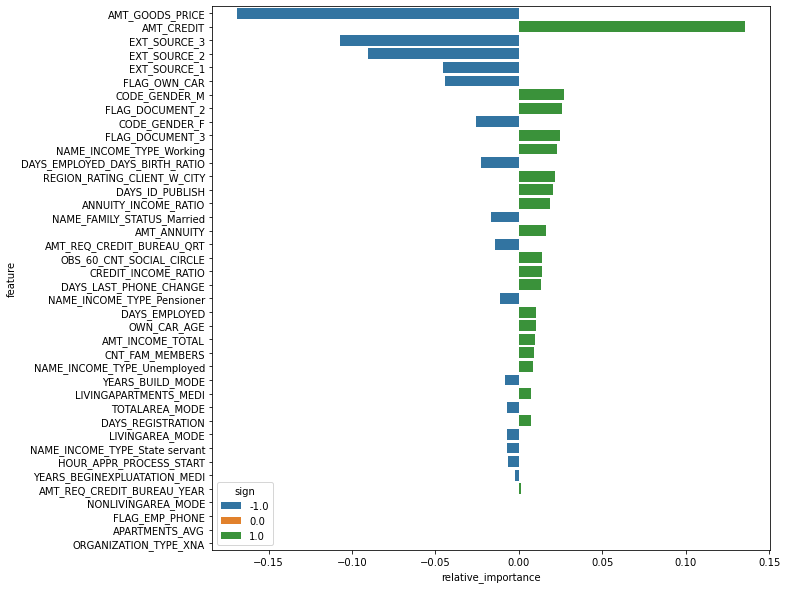

In [339]:
    features_importance_lg(CV_sgd.best_estimator_.named_steps['sgd'],selected_features_busi,plot=True) 

In [341]:
show_score(y_test_busi,CV_sgd.best_estimator_.predict_proba(X_test_busi)[:,1],CV_sgd.best_estimator_.predict(X_test_busi))

ROC AUC   : 0.7391082943076127
F1        : 0.2539388322520853
Accuracy  : 0.685867279467557
Precision : 0.15714012617090423
Recall    : 0.6613032984714401


In [342]:
CV_sgd.best_estimator_.fit(X_busi,y_busi)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('sgd',
                 SGDClassifier(alpha=0.01, class_weight='balanced',
                               l1_ratio=0.1, loss='modified_huber',
                               max_iter=2000, penalty='elasticnet'))])

In [343]:
kaggle_submit(CV_sgd.best_estimator_,app_kaggle_busi,'sgd_optimized.csv')

### LGB

In [268]:
pipeline_lgb_tuning = Pipeline(
                                    [('imp', SimpleImputer(strategy='median')),
                                     ('scaler', StandardScaler()),
                                     ('lgb', LGBMClassifier(class_weight='balanced'))]
                                    )

In [345]:
CV_lgb = GridSearchCV(pipeline_lgb_tuning,
                  param_grid = {'lgb__num_leaves':[170,180,190,200,210,220,230],
                                'lgb__learning_rate':[0.1],
                                'lgb__n_estimators':[200]},
                  scoring = score,
                  verbose=True,
                  cv=3)

In [346]:
CV_lgb.fit(X_train_busi, y_train_busi) 

Fitting 3 folds for each of 7 candidates, totalling 21 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  21 out of  21 | elapsed:  6.0min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imp',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('lgb',
                                        LGBMClassifier(class_weight='balanced'))]),
             param_grid={'lgb__learning_rate': [0.1],
                         'lgb__n_estimators': [200],
                         'lgb__num_leaves': [170, 180, 190, 200, 210, 220,
                                             230]},
             scoring='f1', verbose=True)

In [347]:
show_performance(CV_lgb)

best parameter : {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 200}
Cross validation results :
f1 = 0.285 (+/-0.005) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 170}
f1 = 0.284 (+/-0.003) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 180}
f1 = 0.284 (+/-0.006) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 190}
f1 = 0.285 (+/-0.006) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 200}
f1 = 0.283 (+/-0.007) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 210}
f1 = 0.283 (+/-0.008) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 220}
f1 = 0.282 (+/-0.005) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 230}


In [384]:
CV_lgb.fit(X_train_res, y_train_res) 

Fitting 3 folds for each of 7 candidates, totalling 21 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  21 out of  21 | elapsed:  2.1min finished


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('imp',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('lgb',
                                        LGBMClassifier(class_weight='balanced'))]),
             param_grid={'lgb__learning_rate': [0.1],
                         'lgb__n_estimators': [200],
                         'lgb__num_leaves': [170, 180, 190, 200, 210, 220,
                                             230]},
             scoring='f1', verbose=True)

In [385]:
show_performance(CV_lgb)

best parameter : {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 170}
Cross validation results :
f1 = 0.306 (+/-0.009) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 170}
f1 = 0.295 (+/-0.017) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 180}
f1 = 0.289 (+/-0.003) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 190}
f1 = 0.289 (+/-0.008) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 200}
f1 = 0.284 (+/-0.012) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 210}
f1 = 0.285 (+/-0.009) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 220}
f1 = 0.281 (+/-0.008) for {'lgb__learning_rate': 0.1, 'lgb__n_estimators': 200, 'lgb__num_leaves': 230}


In [348]:
show_score(y_test,CV_lgb.best_estimator_.predict_proba(X_test_busi)[:,1],CV_lgb.best_estimator_.predict(X_test_busi))

ROC AUC   : 0.7399678177668205
F1        : 0.28623736368701747
Accuracy  : 0.805601925119778
Precision : 0.2035318089200815
Recall    : 0.48216680075087154


In [349]:
CV_lgb.best_estimator_.fit(X_busi,y_busi)

Pipeline(steps=[('imp', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('lgb',
                 LGBMClassifier(class_weight='balanced', n_estimators=200,
                                num_leaves=200))])

In [350]:
kaggle_submit(CV_lgb.best_estimator_,app_kaggle_busi,'lgb_optimized.csv')

#### Submitting to kaggle

In [ ]:
def kaggle_submit(estimator,data,output_name = 'submission_default.csv'):
    kaggle_pred = estimator.predict(data)
    kaggle_df = pd.DataFrame(data['SK_ID_CURR'],columns=['SK_ID_CURR'])
    kaggle_df['TARGET'] = kaggle_pred
    kaggle_df.to_csv('data/'+output_name,index = False)

In [68]:
# Class Unbalance

In [ ]:
plt.hist(y_train)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count')
plt.show()

In [ ]:
## Class unbalanced strategy

In [ ]:
### Over sampling

In [ ]:
X_up,y_up = resample(X_train_std[y_train == 1],
                     y_train[y_train == 1],
                     replace=True,
                     n_samples=X_train_std[y_train == 0].shape[0])

X_train_up = np.vstack((X_train_std[y_train == 0], X_up))
y_train_up = np.hstack((y_train[y_train == 0], y_up))

plt.hist(y_train_up)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count with resampling')
plt.show()

In [ ]:
### Data augmentation Using SMOTE

In [ ]:
oversample = imblearn.over_sampling.SMOTE(sampling_strategy = 0.4)
undersample = imblearn.under_sampling.RandomUnderSampler(sampling_strategy = 0.7)

pipeline_smote = imblearn.pipeline.Pipeline(steps = [('over',oversample),('under',undersample)])

X_train_smote,y_train_smote = pipeline_smote.fit_resample(X_train_std,y_train)

plt.hist(y_train_smote)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count with SMOTE')
plt.show()